# Utilizando a biblioteca DARTS para forecasting
## Notebook desenvolvido para o curso Financial Analytics - Insper
Referências:
- https://unit8.com/resources/darts-time-series-made-easy-in-python/
- https://levelup.gitconnected.com/a-python-library-that-makes-it-simple-to-forecast-time-series-6a403da71542
- https://pypi.org/project/statsforecast/

### 1. Imports and data upload

In [ ]:
%%capture
# DARTS now is lightweight install: please see
# https://github.com/unit8co/darts/blob/master/INSTALL.md#enabling-optional-dependencies
# Descomente se for rodar pela primeira vez:
!pip install darts prophet statsforecast


In [14]:
from darts.models import (
    NaiveSeasonal,
    NaiveDrift,
    Prophet,
    ExponentialSmoothing,
    ARIMA,
    AutoARIMA,
    TBATS
)

from darts import TimeSeries
from darts.metrics import mape, mase, mae, mse, ope, r2_score, rmse, rmsle
from statsmodels.tsa.stattools import adfuller

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# importing data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates = ['Month'],index_col = ['Month'])
series = TimeSeries.from_dataframe(df)

In [3]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [4]:
# split train and test using DARTS split features
train, val = series.split_before(pd.Timestamp('19600101'))

In [5]:
train

<TimeSeries (Month: 132, component: 1, sample: 1)> Size: 1kB
array([[[112.]],

       [[118.]],

       [[132.]],

       [[129.]],

       [[121.]],

       [[135.]],

       [[148.]],

       [[148.]],

       [[136.]],

       [[119.]],

...

       [[406.]],

       [[396.]],

       [[420.]],

       [[472.]],

       [[548.]],

       [[559.]],

       [[463.]],

       [[407.]],

       [[362.]],

       [[405.]]])
Coordinates:
  * Month      (Month) datetime64[ns] 1kB 1949-01-01 1949-02-01 ... 1959-12-01
  * component  (component) object 8B 'Passengers'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

### 2. Quick example on how to use DARTS

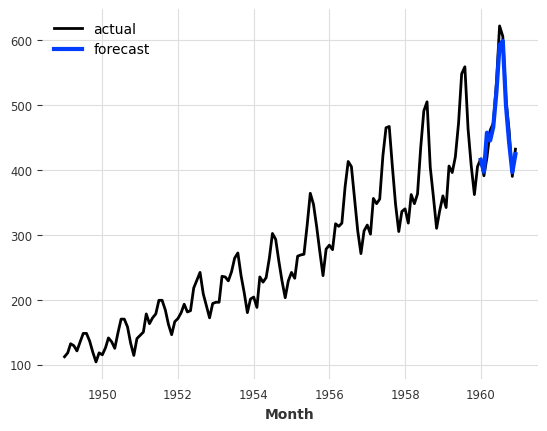

In [8]:
# training a Exponential Smoothing model and plotting prediction
model = ExponentialSmoothing()
model.fit(train)
prediction = model.predict(len(val))

series.plot(label='actual')
prediction.plot(label='forecast', lw=3)
plt.legend();



In [9]:
series

<TimeSeries (Month: 144, component: 1, sample: 1)> Size: 1kB
array([[[112.]],

       [[118.]],

       [[132.]],

       [[129.]],

       [[121.]],

       [[135.]],

       [[148.]],

       [[148.]],

       [[136.]],

       [[119.]],

...

       [[419.]],

       [[461.]],

       [[472.]],

       [[535.]],

       [[622.]],

       [[606.]],

       [[508.]],

       [[461.]],

       [[390.]],

       [[432.]]])
Coordinates:
  * Month      (Month) datetime64[ns] 1kB 1949-01-01 1949-02-01 ... 1960-12-01
  * component  (component) object 8B 'Passengers'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

### 3. Testing for stationarity

In [11]:
# get order of first differencing: the higher of KPSS and ADF test results
result = adfuller(series.to_dataframe())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))
if result[1] <= 0.05:
    print("Reject the null hypothesis: The series is stationary")
else:
    print("Fail to reject the null hypothesis: The series is non-stationary")

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579
Fail to reject the null hypothesis: The series is non-stationary


### 4. Algorithms setup: setting the algorithm's hyparameters

In [12]:
# exponential smoothing
m_expon = ExponentialSmoothing()

# prepare Prophet forecaster: multiplicative seas
m_prophet_m = Prophet(seasonality_mode="multiplicative")

# prepare Prophet forecaster: additive seas
m_prophet_a = Prophet(seasonality_mode="additive")

# prepare autoARIMA from StatsForecast
m_autoarima_stats = AutoARIMA(season_length=12)

In [13]:
# list of models to be evaluated

models = [
    m_expon,
    m_prophet_m,
    m_prophet_a,
    m_autoarima_stats]

### 5. Creating an evaluating function to run many models

In [15]:
## fit the chosen forecaster model and compute predictions

def eval_model(model, train, val):
    t_start =  time.perf_counter()
    print("beginning: " + str(model))


    # fit the model and compute predictions
    res = model.fit(train)
    forecast = model.predict(len(val))

    # compute accuracy metrics and processing time
    res_mape = mape(val, forecast)
    res_mae = mae(val, forecast)
    res_r2 = r2_score(val, forecast)
    res_rmse = rmse(val, forecast)
    res_rmsle = rmsle(val, forecast)
    res_time = time.perf_counter() - t_start
    res_accuracy = {"MAPE":res_mape, "MAE":res_mae, "R squared":-res_r2, "RMSE":res_rmse, "RMSLE":res_rmsle, "time":res_time}

    results = [forecast, res_accuracy, res]
    print("completed: " + str(model) + ":" + str(res_time) + "sec")
    return results

In [16]:
eval_model(m_prophet_m, train, val)[1]

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsmrsqidc/46addqmn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsmrsqidc/go38u1f_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93078', 'data', 'file=/tmp/tmpsmrsqidc/46addqmn.json', 'init=/tmp/tmpsmrsqidc/go38u1f_.json', 'output', 'file=/tmp/tmpsmrsqidc/prophet_modelsh24rfd8/prophet_model-20251027112503.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:25:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


beginning: Prophet(seasonality_mode=multiplicative)


11:25:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


completed: Prophet(seasonality_mode=multiplicative):0.27867658200011647sec


{'MAPE': np.float64(4.443829749162533),
 'MAE': np.float64(21.908813279003937),
 'R squared': np.float64(-0.8794305116779759),
 'RMSE': np.float64(25.84359362409569),
 'RMSLE': np.float64(0.05137792905621055),
 'time': 0.27867658200011647}

In [17]:
eval_model(m_autoarima_stats, train, val)[1]

beginning: AutoARIMA(season_length=12)
completed: AutoARIMA(season_length=12):0.7895365719998608sec


{'MAPE': np.float64(4.1796926177437514),
 'MAE': np.float64(18.515823497791207),
 'R squared': np.float64(-0.8967154852992124),
 'RMSE': np.float64(23.919483693648484),
 'RMSLE': np.float64(0.05350335125515268),
 'time': 0.7895365719998608}

Running all the models

In [18]:
# call the forecasters one after the other
model_predictions = [eval_model(model, train, val) for model in models]

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsmrsqidc/br4f6u2o.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsmrsqidc/ndqs0vnm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99610', 'data', 'file=/tmp/tmpsmrsqidc/br4f6u2o.json', 'init=/tmp/tmpsmrsqidc/ndqs0vnm.json', 'output', 'file=/tmp/tmpsmrsqidc/prophet_model7l53bls7/prophet_model-20251027112533.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:25:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


beginning: ExponentialSmoothing()
completed: ExponentialSmoothing():0.12557467699980407sec
beginning: Prophet(seasonality_mode=multiplicative)


11:25:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsmrsqidc/a5aacn1w.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsmrsqidc/t23uv7jp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=15503', 'data', 'file=/tmp/tmpsmrsqidc/a5aacn1w.json', 'init=/tmp/tmpsmrsqidc/t23uv7jp.json', 'output', 'file=/tmp/tmpsmrsqidc/prophet_modelhvm5g455/prophet_model-20251027112533.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:25:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:25:33 - cmdstanpy - INFO - Chain [1] 

completed: Prophet(seasonality_mode=multiplicative):0.13173181999991357sec
beginning: Prophet(seasonality_mode=additive)
completed: Prophet(seasonality_mode=additive):0.09849881199988886sec
beginning: AutoARIMA(season_length=12)
completed: AutoARIMA(season_length=12):0.37064578100012113sec


In [19]:
# RUN the forecasters and tabulate their prediction accuracy and processing time

df_acc = pd.DataFrame.from_dict(model_predictions[0][1], orient="index")
df_acc.columns = [str(models[0])]

for i, m in enumerate(models):
    if i > 0:
        df = pd.DataFrame.from_dict(model_predictions[i][1], orient="index")
        df.columns = [str(m)]
        df_acc = pd.concat([df_acc, df], axis=1)
    i +=1

pd.set_option("display.precision",3)
df_acc.style.highlight_min(color="lightgreen", axis=1).highlight_max(color="yellow", axis=1)


,ExponentialSmoothing(),Prophet(seasonality_mode=multiplicative),Prophet(seasonality_mode=additive),AutoARIMA(season_length=12)
MAPE,2.803136,4.443830,6.614227,4.179693
MAE,13.382162,21.908813,33.434485,18.515823
R squared,-0.947945,-0.879431,-0.665160,-0.896715
RMSE,16.981068,25.843594,43.067799,23.919484
RMSLE,0.035501,0.051378,0.081915,0.053503
time,0.125575,0.131732,0.098499,0.370646


### 6. Cross validation using DARTS

In [26]:
import logging

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled=True

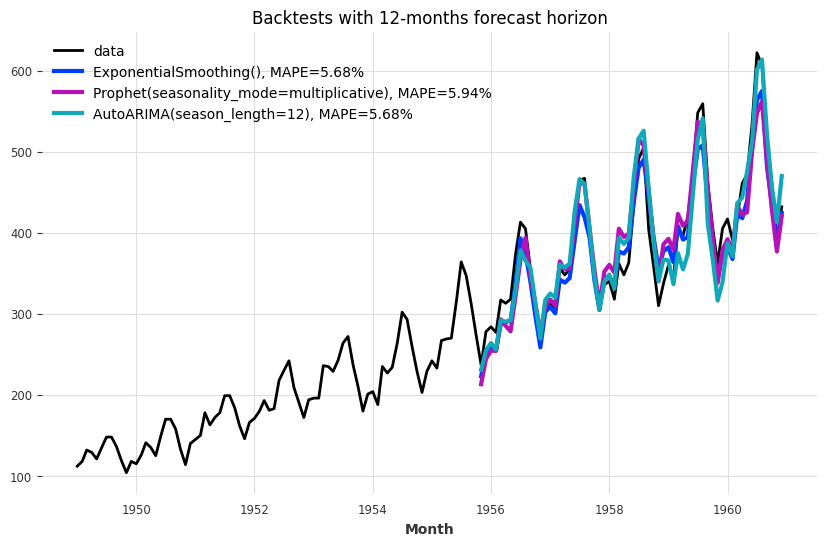

In [27]:
models_backtest = [m_expon, m_prophet_m, m_autoarima_stats]
backtests = [model.historical_forecasts(series, start=.5, forecast_horizon=12) for model in models_backtest]

plt.figure(figsize=(10, 6))
series.plot(label='data')
for i, m in enumerate(models_backtest):
    err = mape(backtests[i], series)
    backtests[i].plot(lw=3, label='{}, MAPE={:.2f}%'.format(m, err))

plt.title('Backtests with 12-months forecast horizon')
plt.legend()